<a href="https://colab.research.google.com/github/binharseneuit/IntroToML/blob/main/ML107/TitanicNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Neural Net

## Data

In [1]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_string = "/content/drive/My Drive/titanic.csv"
data = pd.read_csv(file_string)
data

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1.0,1.0,female,29.0000,0.0,0.0,211.3375,S
1,1.0,1.0,male,0.9167,1.0,2.0,151.5500,S
2,1.0,0.0,female,2.0000,1.0,2.0,151.5500,S
3,1.0,0.0,male,30.0000,1.0,2.0,151.5500,S
4,1.0,0.0,female,25.0000,1.0,2.0,151.5500,S
...,...,...,...,...,...,...,...,...
1305,3.0,0.0,female,NaN,1.0,0.0,14.4542,C
1306,3.0,0.0,male,26.5000,0.0,0.0,7.2250,C
1307,3.0,0.0,male,27.0000,0.0,0.0,7.2250,C
1308,3.0,0.0,male,29.0000,0.0,0.0,7.8750,S


## Preprocessing

In [4]:
data.isnull().sum()

,0
pclass,1
survived,1
sex,1
age,264
sibsp,1
parch,1
fare,2
embarked,3


In [5]:
data = data.dropna(axis=0)
data

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1.0,1.0,female,29.0000,0.0,0.0,211.3375,S
1,1.0,1.0,male,0.9167,1.0,2.0,151.5500,S
2,1.0,0.0,female,2.0000,1.0,2.0,151.5500,S
3,1.0,0.0,male,30.0000,1.0,2.0,151.5500,S
4,1.0,0.0,female,25.0000,1.0,2.0,151.5500,S
...,...,...,...,...,...,...,...,...
1301,3.0,0.0,male,45.5000,0.0,0.0,7.2250,C
1304,3.0,0.0,female,14.5000,1.0,0.0,14.4542,C
1306,3.0,0.0,male,26.5000,0.0,0.0,7.2250,C
1307,3.0,0.0,male,27.0000,0.0,0.0,7.2250,C


In [6]:
data = pd.get_dummies(data)

data

,pclass,survived,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1.0,1.0,29.0000,0.0,0.0,211.3375,True,False,False,False,True
1,1.0,1.0,0.9167,1.0,2.0,151.5500,False,True,False,False,True
2,1.0,0.0,2.0000,1.0,2.0,151.5500,True,False,False,False,True
3,1.0,0.0,30.0000,1.0,2.0,151.5500,False,True,False,False,True
4,1.0,0.0,25.0000,1.0,2.0,151.5500,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1301,3.0,0.0,45.5000,0.0,0.0,7.2250,False,True,True,False,False
1304,3.0,0.0,14.5000,1.0,0.0,14.4542,True,False,True,False,False
1306,3.0,0.0,26.5000,0.0,0.0,7.2250,False,True,True,False,False
1307,3.0,0.0,27.0000,0.0,0.0,7.2250,False,True,True,False,False


In [7]:
X = data.drop(["survived", "sex_male"], axis=1)
y = data["survived"]
X

,pclass,age,sibsp,parch,fare,sex_female,embarked_C,embarked_Q,embarked_S
0,1.0,29.0000,0.0,0.0,211.3375,True,False,False,True
1,1.0,0.9167,1.0,2.0,151.5500,False,False,False,True
2,1.0,2.0000,1.0,2.0,151.5500,True,False,False,True
3,1.0,30.0000,1.0,2.0,151.5500,False,False,False,True
4,1.0,25.0000,1.0,2.0,151.5500,True,False,False,True
...,...,...,...,...,...,...,...,...,...
1301,3.0,45.5000,0.0,0.0,7.2250,False,True,False,False
1304,3.0,14.5000,1.0,0.0,14.4542,True,True,False,False
1306,3.0,26.5000,0.0,0.0,7.2250,False,True,False,False
1307,3.0,27.0000,0.0,0.0,7.2250,False,True,False,False


### Loading the Preprocessed Data Into the DataLoader

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

X_tensors = torch.from_numpy(X.astype(float).values).float().to(device)
y_tensors = torch.from_numpy(y.astype(float).values).float().to(device)

X_train, X_test, y_train, y_test = train_test_split(X_tensors, y_tensors, test_size=0.2, train_size=0.8, random_state=42)

cuda


In [10]:
from torch.utils.data import Dataset, DataLoader
class TitanicDataset(Dataset):

    def __init__(self, X_train, y_train):
        self.x_data, self.y_data = X_train, y_train

    def __getitem__(self, i):
        return self.x_data[i], self.y_data[i]

    def __len__(self):
      return len(self.y_data)

titanic_data = TitanicDataset(X_train, y_train)

In [11]:
batch_size = 100
loader = DataLoader(dataset=titanic_data, batch_size=batch_size, shuffle=True)

## Model

In [12]:
class TitanicModel(nn.Module):

  def __init__(self):
    super(TitanicModel, self).__init__()
    # input layer
    self.input_layer_to_hidden_layer_1 = nn.Linear(9,20)
    # relu 1
    self.relu1 = nn.ReLU()

    # hidden layer 1
    self.hidden_layer_1_to_hidden_layer_2 = nn.Linear(20,2)
    # relu 2
    self.relu2 = nn.ReLU()

    # hidden layer 2
    self.hidden_layer_2_to_output_layer = nn.Linear(2,1)
    # sigmoid 3
    self.sigmoid3 = nn.Sigmoid()

  def forward(self, input):

    # input layer
    linear_combination1 = self.input_layer_to_hidden_layer_1(input)
    intermediate_relu1 = self.relu1(linear_combination1)

    # hidden layer 1
    linear_combination2 = self.hidden_layer_1_to_hidden_layer_2(intermediate_relu1)
    intermediate_relu2 = self.relu2(linear_combination2)

    # hidden layer 2
    linear_combination3 = self.hidden_layer_2_to_output_layer(intermediate_relu2)
    out = self.sigmoid3(linear_combination3)
    return out

## Training

In [13]:
titanic = TitanicModel().to(device)
epochs = 3000
optimizer = torch.optim.Adam(titanic.parameters(), lr = 0.01)
loss_function = torch.nn.BCELoss()

torch.manual_seed(42)
losses = []
for epoch in range(epochs):
  mini_batch_losses = []
  for i, (features, labels) in enumerate(loader):

    Y_prediction = titanic.forward(features)

    loss = loss_function(Y_prediction, labels.unsqueeze(1))

    titanic.zero_grad()

    loss.backward()

    optimizer.step()

    # keep track of losses
    mini_batch_losses.append(loss.detach().cpu().numpy()) # we can only execute numpy code on the cpu

  mini_batch_mean_loss = np.mean(mini_batch_losses)
  losses.append(mini_batch_mean_loss)
  if epoch % 200 == 0:
    print(f"Loss in Epoch {epoch}: {np.mean(losses)}")

Loss in Epoch 0: 0.6874780058860779
Loss in Epoch 200: 0.6763778328895569
Loss in Epoch 400: 0.6765467524528503
Loss in Epoch 600: 0.676491916179657
Loss in Epoch 800: 0.6764625906944275
Loss in Epoch 1000: 0.6764882802963257
Loss in Epoch 1200: 0.6764839887619019
Loss in Epoch 1400: 0.6765068173408508
Loss in Epoch 1600: 0.6765278577804565
Loss in Epoch 1800: 0.6765340566635132
Loss in Epoch 2000: 0.6765538454055786
Loss in Epoch 2200: 0.6765627264976501
Loss in Epoch 2400: 0.6765491962432861
Loss in Epoch 2600: 0.6765507459640503
Loss in Epoch 2800: 0.676547646522522


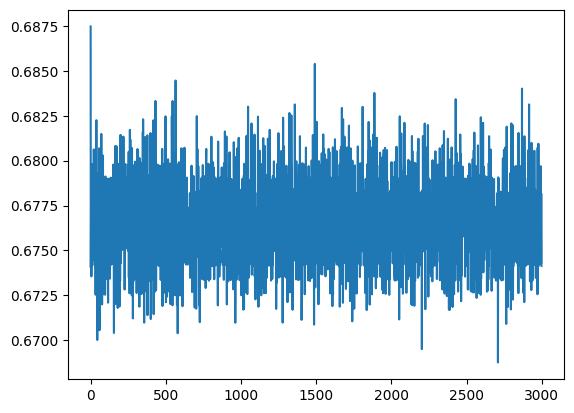

In [14]:
plt.figure()
plt.plot(losses)

## Testing

In [16]:
y_test_predictions = titanic.forward(X_test)

In [18]:
y_test_predictions_thresholded = (y_test_predictions > 0.5) * 1

In [19]:
from sklearn.metrics import accuracy_score
total_records = len(y_test)
num_correct = accuracy_score(y_test.detach().cpu().numpy(), y_test_predictions_thresholded.detach().cpu().numpy(), normalize=False) # normalize would round up to an integer, so we set it False
print(num_correct / total_records)

0.5980861244019139
